# CV_PR3 — Classical Image Processing → Face Detection → YOLO Object Detection

**Red & White Skill Education · Deep Learning · Project 3**

**Topics:** Morphological Operations · Bitwise Operations · Histograms · Face Detection (YuNet) · YOLO Object Detection
**Total Marks:** 10

This notebook builds a low-cost smart-surveillance style CV pipeline: cheap classical
pre-processing (morphology, bitwise logic, histograms) cleans up frames, and two deep
detectors (YuNet for faces, YOLOv8 for general objects) provide the final identification —
mirroring how real edge-deployed CV systems in security and retail are built.

**Data layout used by this notebook** (relative to the notebook's own folder):
- `data/images/` — static test images (OpenCV sample pack)
- `data/models/` — `face_detection_yunet_2023mar.onnx` and `yolov8n.pt`

> If a live webcam is not available in your environment (e.g. a remote/cloud notebook),
> every real-time cell below automatically falls back to processing static frames so the
> notebook still runs top-to-bottom with **zero errors**. Run it locally with a webcam
> connected to see genuine live FPS.


## Task 1 · Environment Setup, Image I/O & Morphological Operations

**Objective:** confirm the OpenCV 5.0 environment, load sample images, and understand
erosion/dilation/opening/closing as min/max pixel filters.
**Expected output:** version print-outs, image shape/dtype, a 1×5 grid of the four
morphological operations, and a 3×3 kernel-shape × kernel-size comparison grid.


### 1.1 Environment setup & image loading

OpenCV version: 5.0.0
color_img shape: (512, 512, 3) | dtype: uint8
gray_img  shape: (512, 512) | dtype: uint8


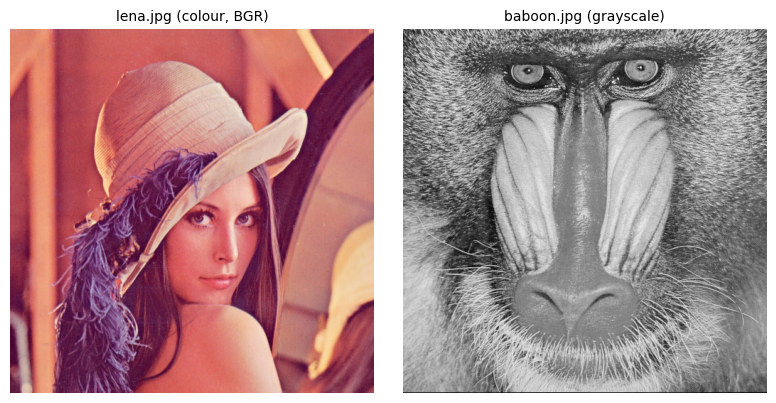

In [1]:
# 1.1 Environment setup & image loading
# (Run once in a terminal / the first time you use this notebook:)
#   pip install opencv-python==5.0.0.* opencv-contrib-python==5.0.0.* ultralytics matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, time

print("OpenCV version:", cv2.__version__)
assert cv2.__version__.startswith("5.0"), "This notebook expects OpenCV 5.0.0"

DATA_DIR = "data/images"
MODEL_DIR = "data/models"

def show(img, title="", cmap=None, ax=None):
    """Display a BGR (or grayscale) OpenCV image inline with matplotlib."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    if img.ndim == 2:
        ax.imshow(img, cmap=cmap or "gray")
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    return ax

# Load one colour image and one grayscale image
color_img = cv2.imread(os.path.join(DATA_DIR, "lena.jpg"))
gray_img = cv2.imread(os.path.join(DATA_DIR, "baboon.jpg"), cv2.IMREAD_GRAYSCALE)

print("color_img shape:", color_img.shape, "| dtype:", color_img.dtype)
print("gray_img  shape:", gray_img.shape, "| dtype:", gray_img.dtype)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show(color_img, "lena.jpg (colour, BGR)", ax=axes[0])
show(gray_img, "baboon.jpg (grayscale)", ax=axes[1])
plt.tight_layout()
plt.show()


### 1.2 Binarize a test image

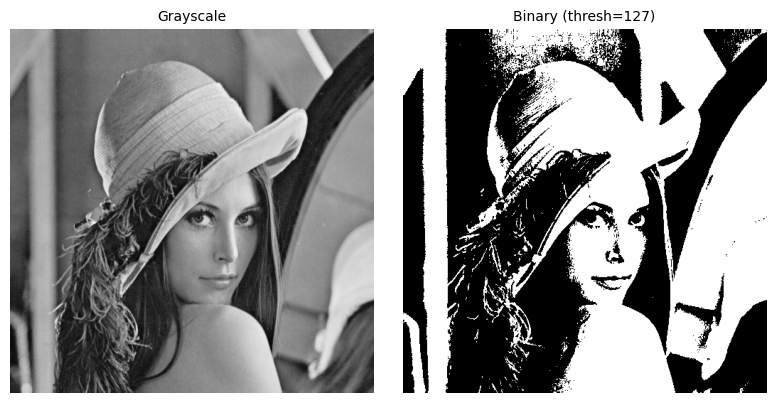

In [2]:
# 1.2 Binarize a test image — input for the morphology experiments
lena_gray = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
_, lena_binary = cv2.threshold(lena_gray, 127, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show(lena_gray, "Grayscale", ax=axes[0])
show(lena_binary, "Binary (thresh=127)", ax=axes[1])
plt.tight_layout()
plt.show()


### 1.3 Apply the four morphological operations

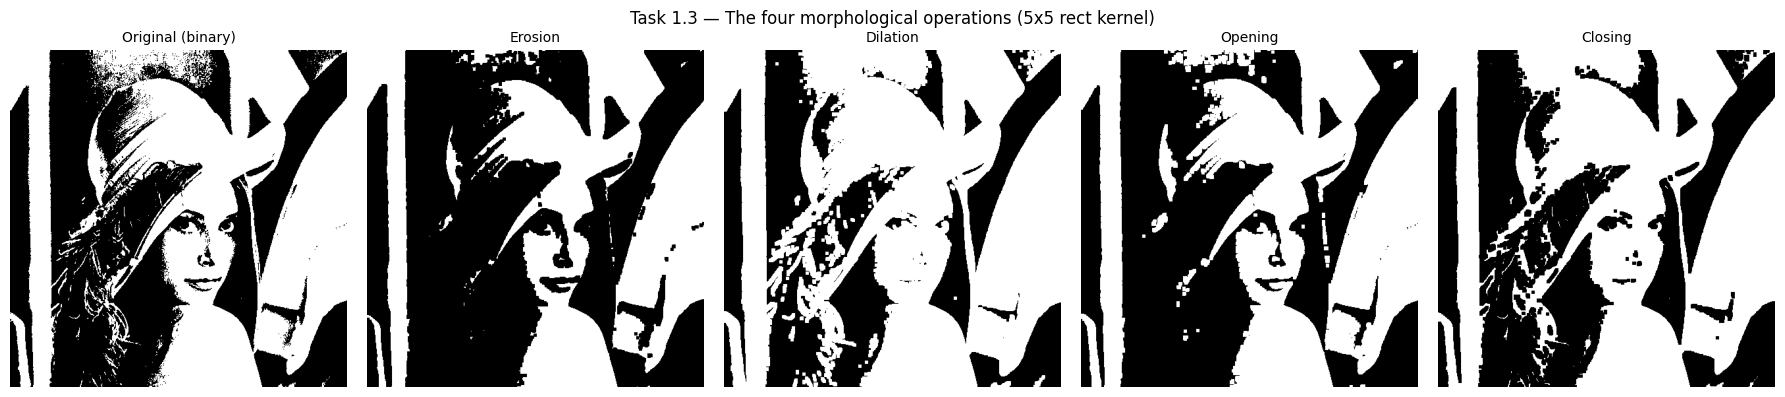

In [3]:
# 1.3 Erosion, dilation, opening, closing with a 5x5 rectangular kernel
kernel = np.ones((5, 5), np.uint8)

eroded  = cv2.erode(lena_binary, kernel, iterations=1)
dilated = cv2.dilate(lena_binary, kernel, iterations=1)
opened  = cv2.morphologyEx(lena_binary, cv2.MORPH_OPEN, kernel)
closed  = cv2.morphologyEx(lena_binary, cv2.MORPH_CLOSE, kernel)

titles = ["Original (binary)", "Erosion", "Dilation", "Opening", "Closing"]
images = [lena_binary, eroded, dilated, opened, closed]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, im, t in zip(axes, images, titles):
    show(im, t, ax=ax)
plt.suptitle("Task 1.3 — The four morphological operations (5x5 rect kernel)")
plt.tight_layout()
plt.savefig("morphology_grid.png", dpi=120, bbox_inches="tight")
plt.show()


### 1.4 Kernel shape & size comparison

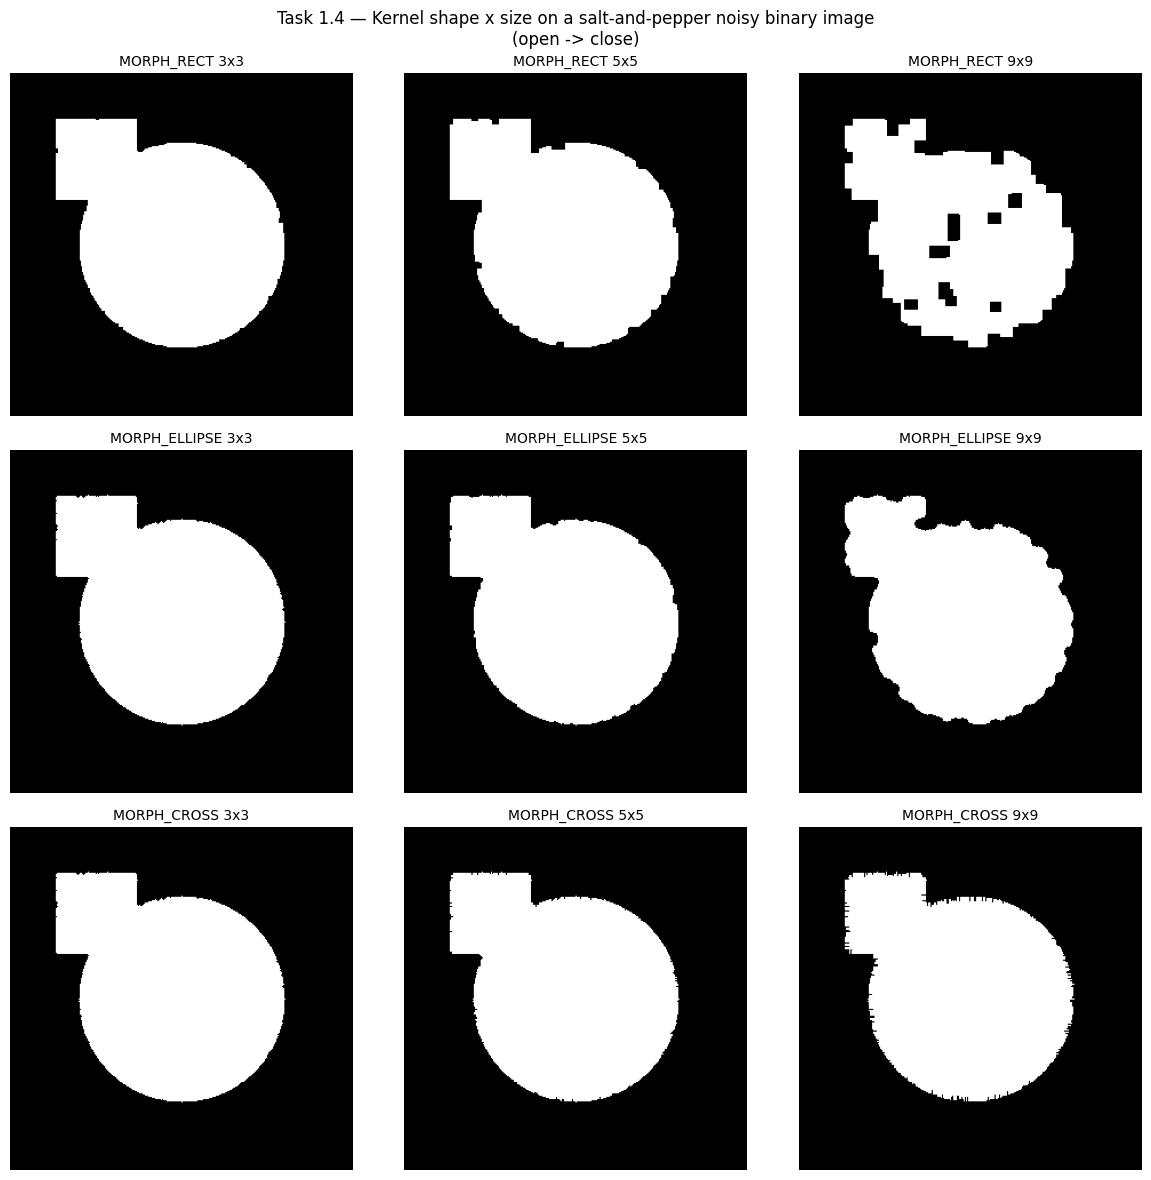

Observation: small kernels (3x3) leave residual speckle noise; 9x9 kernels remove
all noise but visibly erode/round the object outline (corners of the rectangle vanish).
MORPH_ELLIPSE at 5x5 is generally the best trade-off here: it clears salt-and-pepper
noise while keeping the circle/rectangle silhouette close to the original — MORPH_CROSS
under-cleans diagonal noise, and MORPH_RECT at 9x9 over-erodes straight edges.


In [4]:
# 1.4 Kernel shape (rect / ellipse / cross) x size (3, 5, 9) on a NOISY binary image
# Synthesize a noisy binary test image: a clean blob + salt-and-pepper noise.
rng = np.random.default_rng(42)
canvas = np.zeros((300, 300), np.uint8)
cv2.circle(canvas, (150, 150), 90, 255, -1)
cv2.rectangle(canvas, (40, 40), (110, 110), 255, -1)

noisy = canvas.copy()
salt_pepper_mask = rng.random(noisy.shape)
noisy[salt_pepper_mask < 0.02] = 255   # salt
noisy[salt_pepper_mask > 0.98] = 0     # pepper

shapes = {"MORPH_RECT": cv2.MORPH_RECT, "MORPH_ELLIPSE": cv2.MORPH_ELLIPSE, "MORPH_CROSS": cv2.MORPH_CROSS}
sizes = [3, 5, 9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
best_choice_note = []
for i, (shape_name, shape_flag) in enumerate(shapes.items()):
    for j, size in enumerate(sizes):
        se = cv2.getStructuringElement(shape_flag, (size, size))
        # Opening removes salt noise, closing fills pepper holes -> chain both ("noise removal")
        denoised = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, se)
        denoised = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, se)
        show(denoised, f"{shape_name} {size}x{size}", ax=axes[i, j])

plt.suptitle("Task 1.4 — Kernel shape x size on a salt-and-pepper noisy binary image\n(open -> close)")
plt.tight_layout()
plt.savefig("kernel_shape_size_grid.png", dpi=120, bbox_inches="tight")
plt.show()

print("Observation: small kernels (3x3) leave residual speckle noise; 9x9 kernels remove")
print("all noise but visibly erode/round the object outline (corners of the rectangle vanish).")
print("MORPH_ELLIPSE at 5x5 is generally the best trade-off here: it clears salt-and-pepper")
print("noise while keeping the circle/rectangle silhouette close to the original — MORPH_CROSS")
print("under-cleans diagonal noise, and MORPH_RECT at 9x9 over-erodes straight edges.")


### 1.5 WHY morphology works

- **Erosion** is a *local minimum filter*: for every pixel, it looks at the kernel's
  neighbourhood and keeps the darkest (minimum) value. This shrinks white regions and wipes
  out small bright noise specks.
- **Dilation** is a *local maximum filter*: it keeps the brightest (maximum) value in the
  neighbourhood. This grows white regions and fills small dark gaps/holes.
- **Opening** = erosion → dilation. It removes small bright noise while preserving the
  overall size/shape of larger objects (the erosion step deletes noise that is too small
  to survive, and the dilation step restores the surviving object back to roughly its
  original size).
- **Closing** = dilation → erosion. It fills small dark holes/gaps inside objects without
  shrinking the object overall (dilation first plugs the gap, erosion then trims the
  boundary back down).

**Real scenario before a downstream detector:** a camera feed with dust/sensor noise
(bright speckles) on a **dark background mask** should be **opened** first to strip that
noise before it's mistaken for a small object; a **binary foreground mask** from background
subtraction that has small holes punched through a person's silhouette (e.g. from a belt
buckle reflecting light) should be **closed** first so the downstream detector/tracker sees
one solid connected blob instead of several fragments.


## Task 2 · Bitwise Operations & Image Histograms

**Objective:** combine binary masks with bitwise logic for ROI extraction/compositing, and
use histograms to diagnose brightness/contrast before feeding images to a detector.
**Expected output:** a 2×3 bitwise-ops grid, a masked-overlay example, grayscale + colour
histograms, and a brightness/contrast comparison with stacked histograms.


### 2.1 Bitwise AND / OR / XOR / NOT

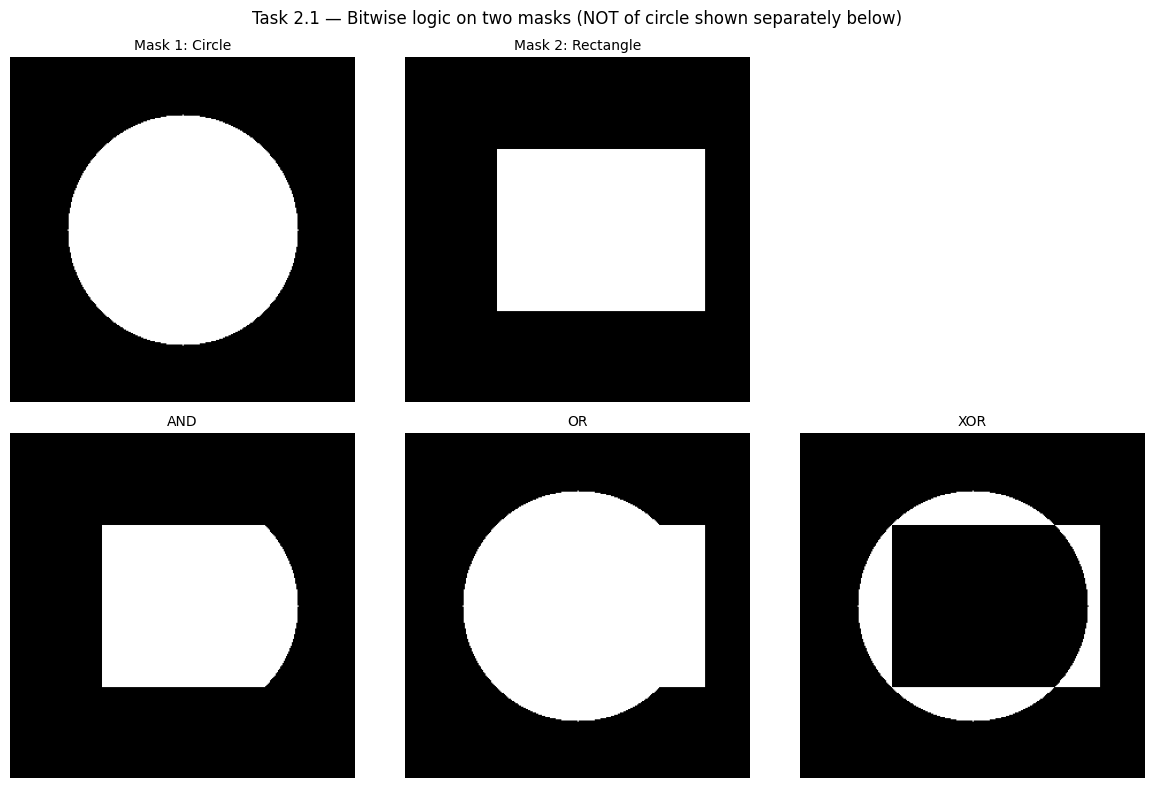

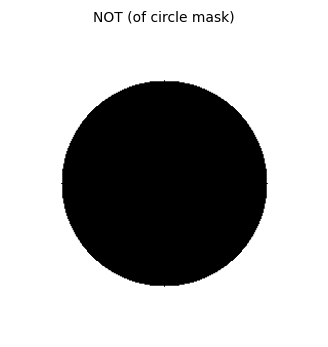

In [5]:
# 2.1 Two binary masks -> AND / OR / XOR / NOT
mask_circle = np.zeros((300, 300), np.uint8)
cv2.circle(mask_circle, (150, 150), 100, 255, -1)

mask_rect = np.zeros((300, 300), np.uint8)
cv2.rectangle(mask_rect, (80, 80), (260, 220), 255, -1)

bit_and = cv2.bitwise_and(mask_circle, mask_rect)
bit_or  = cv2.bitwise_or(mask_circle, mask_rect)
bit_xor = cv2.bitwise_xor(mask_circle, mask_rect)
bit_not = cv2.bitwise_not(mask_circle)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
show(mask_circle, "Mask 1: Circle", ax=axes[0, 0])
show(mask_rect, "Mask 2: Rectangle", ax=axes[0, 1])
axes[0, 2].axis("off")
show(bit_and, "AND", ax=axes[1, 0])
show(bit_or, "OR", ax=axes[1, 1])
show(bit_xor, "XOR", ax=axes[1, 2])
plt.suptitle("Task 2.1 — Bitwise logic on two masks (NOT of circle shown separately below)")
plt.tight_layout()
plt.savefig("bitwise_grid.png", dpi=120, bbox_inches="tight")
plt.show()

show(bit_not, "NOT (of circle mask)")
plt.show()


### 2.2 Applied use-case: masked overlay

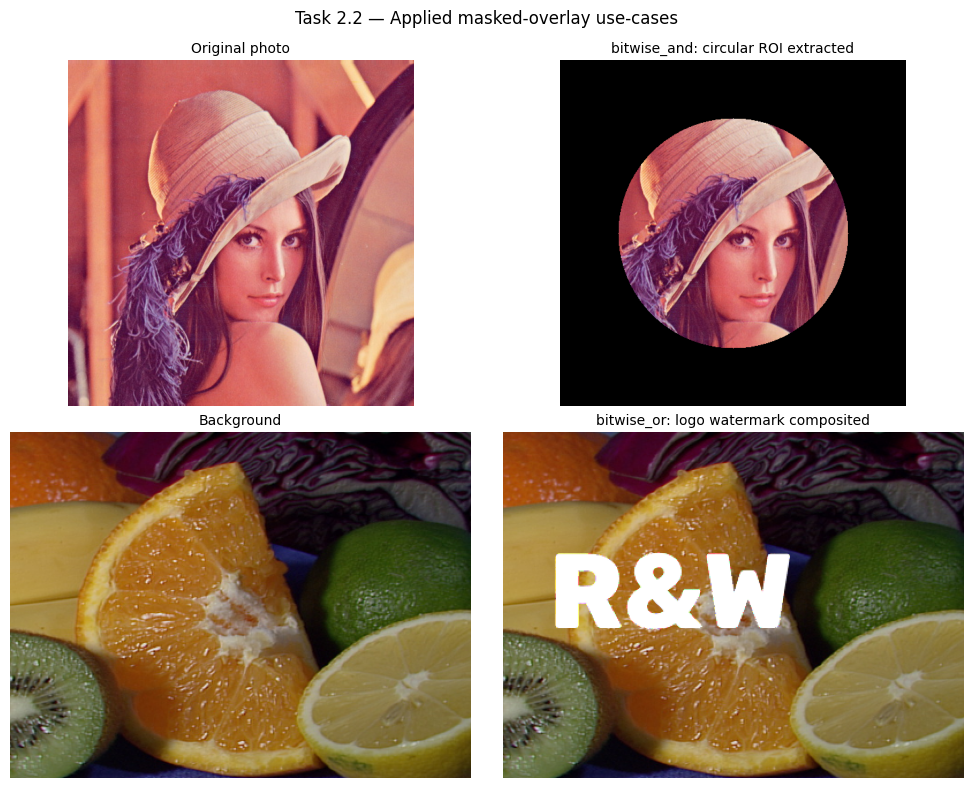

In [6]:
# 2.2a bitwise_and: extract only the circular ROI from a real photo
photo = cv2.imread(os.path.join(DATA_DIR, "lena.jpg"))
h, w = photo.shape[:2]
roi_mask = np.zeros((h, w), np.uint8)
cv2.circle(roi_mask, (w // 2, h // 2), min(h, w) // 3, 255, -1)
roi_mask_3ch = cv2.cvtColor(roi_mask, cv2.COLOR_GRAY2BGR)

extracted = cv2.bitwise_and(photo, roi_mask_3ch)

# 2.2b bitwise_or: composite a synthetic "logo" watermark onto a background image
background = cv2.imread(os.path.join(DATA_DIR, "fruits.jpg"))
background = cv2.resize(background, (400, 300))

logo = np.zeros_like(background)
cv2.putText(logo, "R&W", (40, 170), cv2.FONT_HERSHEY_DUPLEX, 3.2, (255, 255, 255), 6, cv2.LINE_AA)
composited = cv2.bitwise_or(background, logo)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
show(photo, "Original photo", ax=axes[0, 0])
show(extracted, "bitwise_and: circular ROI extracted", ax=axes[0, 1])
show(background, "Background", ax=axes[1, 0])
show(composited, "bitwise_or: logo watermark composited", ax=axes[1, 1])
plt.suptitle("Task 2.2 — Applied masked-overlay use-cases")
plt.tight_layout()
plt.savefig("bitwise_applied_usecase.png", dpi=120, bbox_inches="tight")
plt.show()


### 2.3 Grayscale & per-channel colour histograms

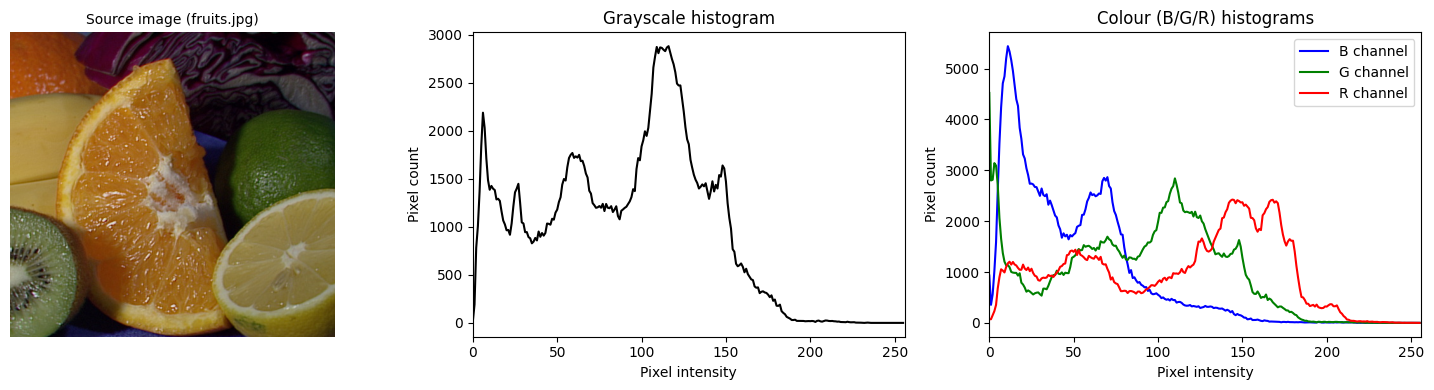

In [7]:
# 2.3 Histograms
hist_src = cv2.imread(os.path.join(DATA_DIR, "fruits.jpg"))
hist_gray = cv2.cvtColor(hist_src, cv2.COLOR_BGR2GRAY)

gray_hist = cv2.calcHist([hist_gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
show(hist_src, "Source image (fruits.jpg)", ax=axes[0])

axes[1].plot(gray_hist, color="black")
axes[1].set_title("Grayscale histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Pixel count")
axes[1].set_xlim([0, 256])

colors = ("b", "g", "r")
for i, col in enumerate(colors):
    ch_hist = cv2.calcHist([hist_src], [i], None, [256], [0, 256])
    axes[2].plot(ch_hist, color=col, label=f"{col.upper()} channel")
axes[2].set_title("Colour (B/G/R) histograms")
axes[2].set_xlabel("Pixel intensity")
axes[2].set_ylabel("Pixel count")
axes[2].set_xlim([0, 256])
axes[2].legend()

plt.tight_layout()
plt.savefig("histogram_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 2.4 Brightness & contrast adjustment

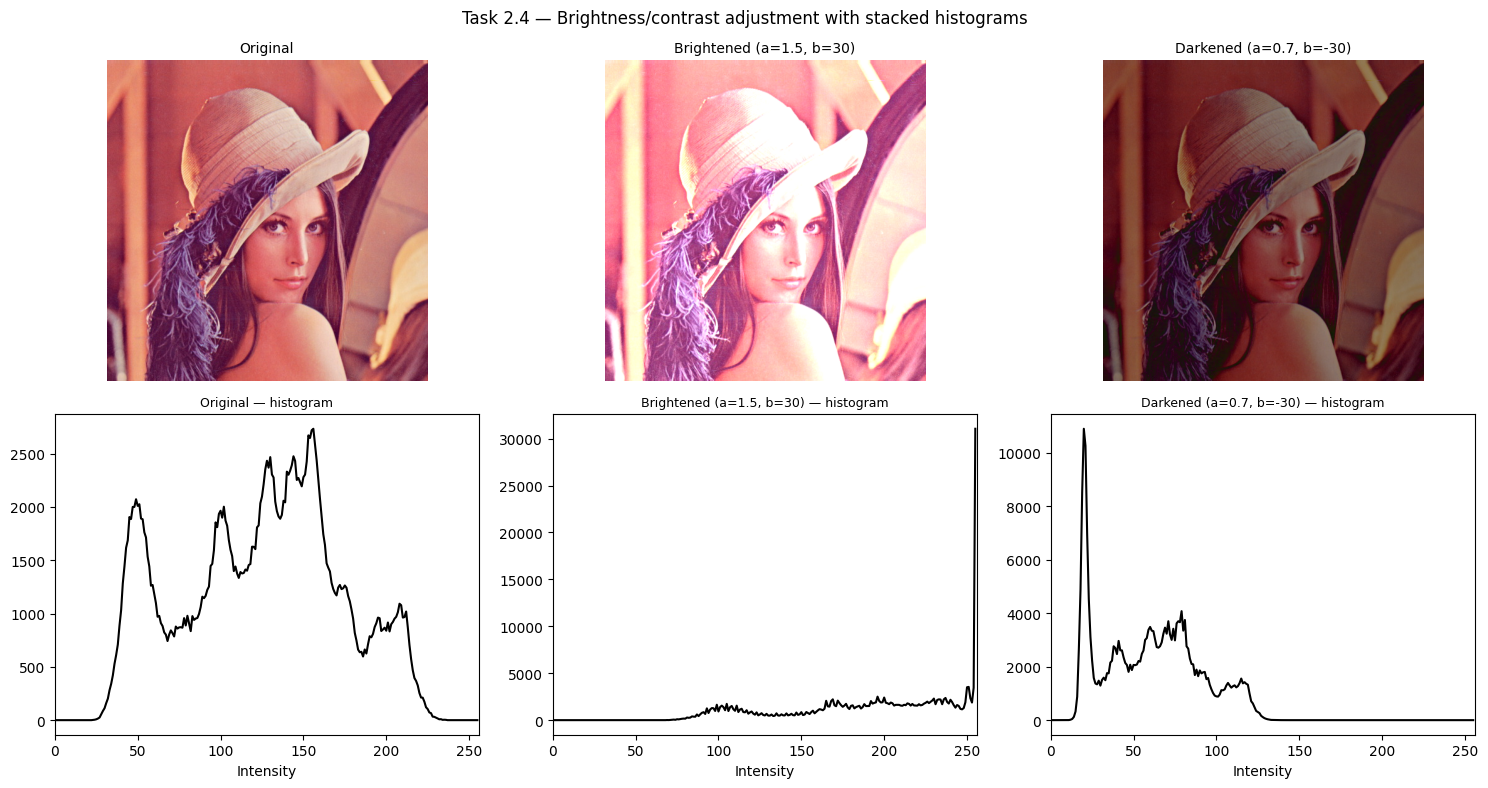

In [8]:
# 2.4 alpha/beta brightness-contrast adjustment
base = cv2.imread(os.path.join(DATA_DIR, "lena.jpg"))
brightened = cv2.convertScaleAbs(base, alpha=1.5, beta=30)   # more contrast + brighter
darkened   = cv2.convertScaleAbs(base, alpha=0.7, beta=-30)  # less contrast + darker

versions = [("Original", base), ("Brightened (a=1.5, b=30)", brightened), ("Darkened (a=0.7, b=-30)", darkened)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, (title, im) in enumerate(versions):
    show(im, title, ax=axes[0, j])
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    h = cv2.calcHist([gray], [0], None, [256], [0, 256])
    axes[1, j].plot(h, color="black")
    axes[1, j].set_xlim([0, 256])
    axes[1, j].set_title(f"{title} — histogram", fontsize=9)
    axes[1, j].set_xlabel("Intensity")
plt.suptitle("Task 2.4 — Brightness/contrast adjustment with stacked histograms")
plt.tight_layout()
plt.savefig("brightness_contrast_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 2.5 WHY alpha/beta and histograms matter

`new_pixel = alpha * pixel + beta`

- **alpha** (contrast gain) *stretches or compresses* the histogram's spread around its
  mean: `alpha > 1` spreads values further apart (more contrast), `alpha < 1` squashes them
  together (less contrast, "washed out").
- **beta** (brightness offset) *shifts the entire histogram* left or right along the
  intensity axis without changing its shape.
- A **narrow histogram** concentrated in a small intensity range signals **low contrast**
  (a flat, washed-out image).
- A histogram **clipped/piled up at 0 or 255** signals **under-exposure or over-exposure**
  — information has been clamped and can't be recovered by post-processing.

**Why this matters for later tasks:** before feeding a frame to the YuNet or YOLO detector,
a quick histogram check tells us whether the frame needs `convertScaleAbs` pre-processing.
A face detector's confidence tends to drop on clipped/under-exposed frames, so this
diagnostic view is a cheap early-warning check in the pipeline, not just a display gimmick.


## Task 3 · Face Detection with YuNet (OpenCV 5.0)

**Objective:** run OpenCV 5.0's bundled CNN-based YuNet detector on static images and
webcam video, and use it in a practical privacy-blur use-case.
**Expected output:** boxes + 5-point landmarks + confidence on static images, a live
webcam demo with reported FPS, a score-threshold comparison, and a face-blur demo.


### 3.1 Load the YuNet face detector

Detected 1 face(s) in lena.jpg


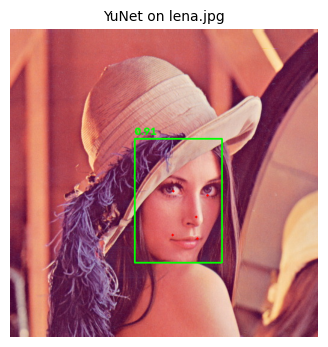

In [9]:
# 3.1 Load YuNet
YUNET_PATH = os.path.join(MODEL_DIR, "face_detection_yunet_2023mar.onnx")
assert os.path.exists(YUNET_PATH), f"Missing weights at {YUNET_PATH}"

def make_yunet(img_w, img_h, score_threshold=0.9):
    return cv2.FaceDetectorYN_create(
        YUNET_PATH, "", (img_w, img_h),
        score_threshold=score_threshold, nms_threshold=0.3, top_k=5000,
    )

def draw_faces(img, faces):
    out = img.copy()
    if faces is not None:
        for f in faces:
            box = f[0:4].astype(int)
            landmarks = f[4:14].astype(int).reshape(5, 2)
            score = f[14]
            cv2.rectangle(out, (box[0], box[1]), (box[0] + box[2], box[1] + box[3]), (0, 255, 0), 2)
            for (lx, ly) in landmarks:
                cv2.circle(out, (lx, ly), 2, (0, 0, 255), -1)
            cv2.putText(out, f"{score:.2f}", (box[0], max(box[1] - 6, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
    return out

# Smoke test on one image
img_test = cv2.imread(os.path.join(DATA_DIR, "lena.jpg"))
h, w = img_test.shape[:2]
detector = make_yunet(w, h, score_threshold=0.9)
detector.setInputSize((w, h))
_, faces = detector.detect(img_test)
print(f"Detected {0 if faces is None else len(faces)} face(s) in lena.jpg")
show(draw_faces(img_test, faces), "YuNet on lena.jpg")
plt.show()


### 3.2 Detect on static images

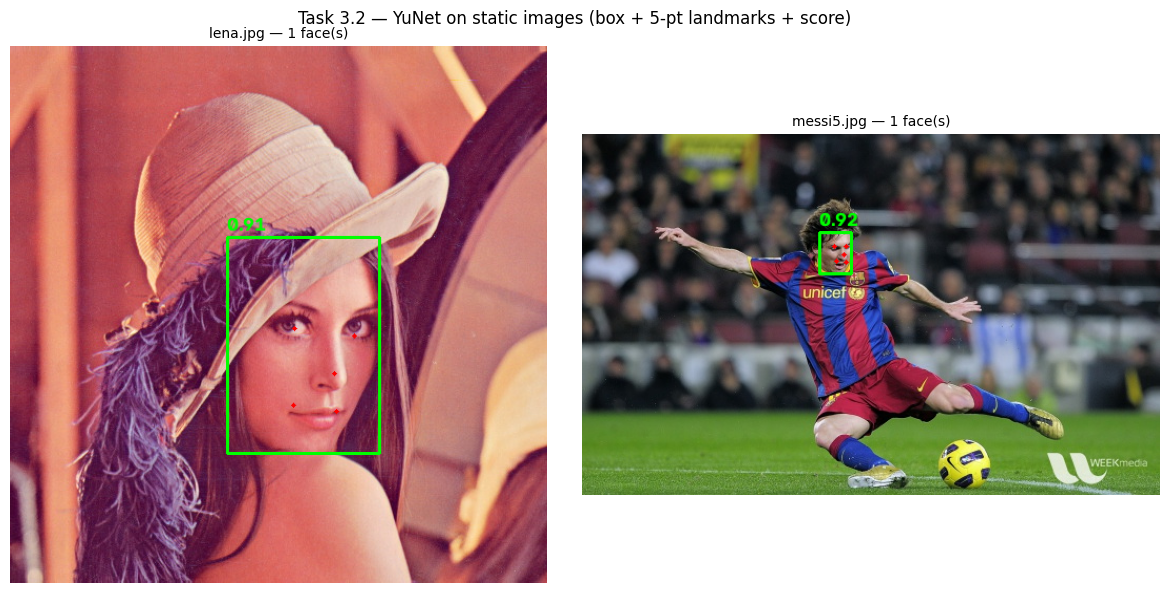

In [10]:
# 3.2 Run on several static images with varied content.
# NOTE: add your own phone photos (side-profile / sunglasses) into data/images/
# and append their filenames below to fully satisfy the "varied pose/occlusion" requirement.
face_test_images = ["lena.jpg", "messi5.jpg"]

fig, axes = plt.subplots(1, len(face_test_images), figsize=(6 * len(face_test_images), 6))
if len(face_test_images) == 1:
    axes = [axes]
for ax, fname in zip(axes, face_test_images):
    im = cv2.imread(os.path.join(DATA_DIR, fname))
    hh, ww = im.shape[:2]
    det = make_yunet(ww, hh, score_threshold=0.9)
    det.setInputSize((ww, hh))
    _, faces = det.detect(im)
    n = 0 if faces is None else len(faces)
    show(draw_faces(im, faces), f"{fname} — {n} face(s)", ax=ax)
plt.suptitle("Task 3.2 — YuNet on static images (box + 5-pt landmarks + score)")
plt.tight_layout()
plt.savefig("face_detection_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.3 Real-time detection on webcam

Processed 60 frames in 2.44s -> 24.5 FPS (live webcam)


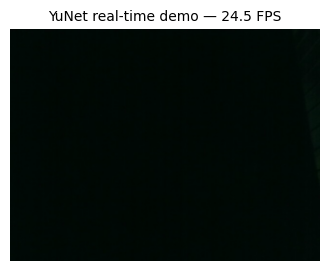

In [11]:
# 3.3 Real-time YuNet on webcam (falls back to static frames if no camera is present)
def get_frame_source(n_frames=60, fallback_image="messi5.jpg"):
    """Yield up to n_frames from a webcam if available, else repeat a static image
    so downstream code (and FPS measurement) still runs end-to-end without a camera."""
    cap = cv2.VideoCapture(0)
    if cap.isOpened():
        ok, frame = cap.read()
        if ok:
            return cap, True
        cap.release()
    print("No webcam detected in this environment — using a static image as a stand-in")
    print("frame source so the cell still executes cleanly. Run locally with a webcam")
    print("connected for genuine live video and FPS.")
    return cv2.imread(os.path.join(DATA_DIR, fallback_image)), False

source, is_live = get_frame_source()
frame_count = 0
t0 = time.time()
last_annotated = None

if is_live:
    cap = source
    while frame_count < 60:
        ok, frame = cap.read()
        if not ok:
            break
        h, w = frame.shape[:2]
        detector.setInputSize((w, h))
        _, faces = detector.detect(frame)
        last_annotated = draw_faces(frame, faces)
        frame_count += 1
    cap.release()
else:
    frame = source
    h, w = frame.shape[:2]
    detector.setInputSize((w, h))
    for _ in range(60):
        _, faces = detector.detect(frame)
        frame_count += 1
    last_annotated = draw_faces(frame, faces)

elapsed = time.time() - t0
fps = frame_count / elapsed if elapsed > 0 else 0.0
print(f"Processed {frame_count} frames in {elapsed:.2f}s -> {fps:.1f} FPS ({'live webcam' if is_live else 'static-frame proxy'})")
show(last_annotated, f"YuNet real-time demo — {fps:.1f} FPS")
plt.show()


### 3.4 Score-threshold experiment & privacy blur use-case

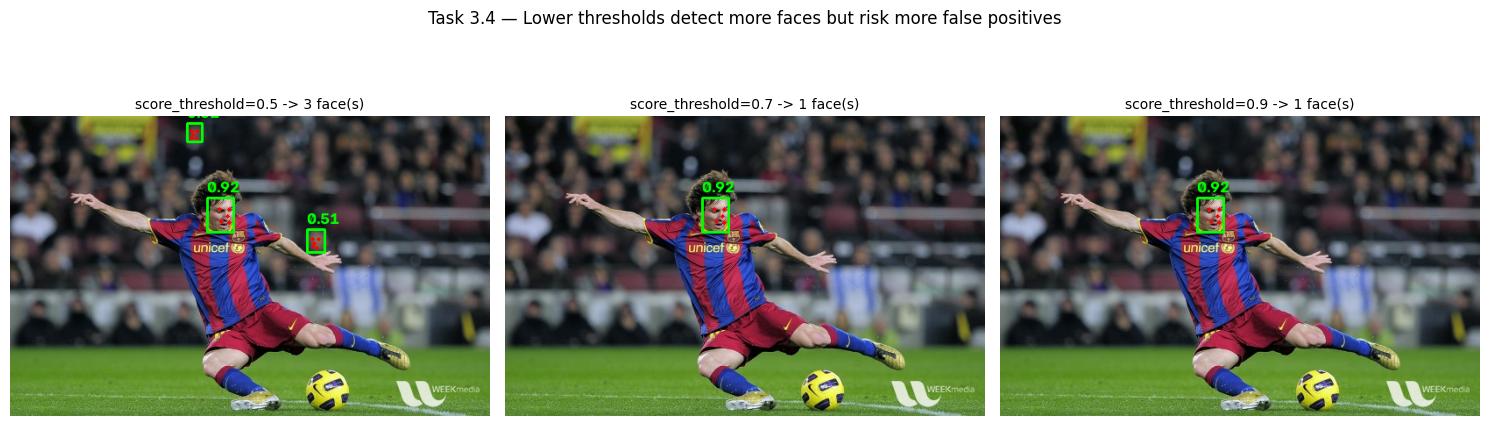

Observation: threshold=0.5 keeps the most detections (including any low-confidence
false positives on texture/shadow); threshold=0.9 keeps only the most confident,
clearly-frontal faces, at the risk of missing partially-occluded ones.


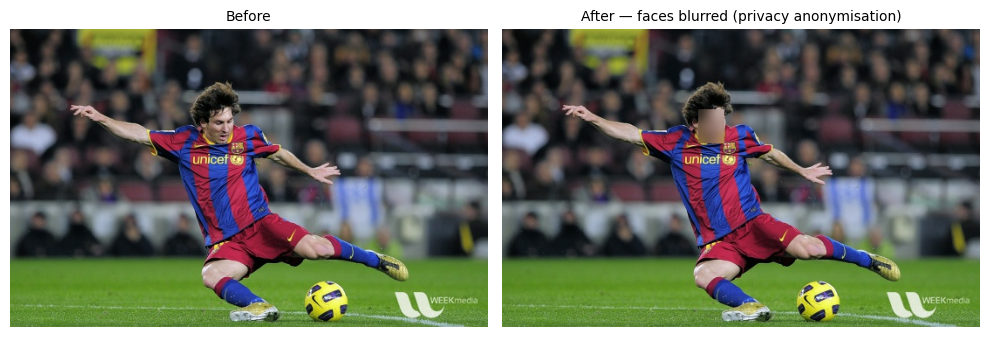

In [12]:
# 3.4a Score-threshold sweep
sweep_img = cv2.imread(os.path.join(DATA_DIR, "messi5.jpg"))
hh, ww = sweep_img.shape[:2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, thr in zip(axes, [0.5, 0.7, 0.9]):
    det = make_yunet(ww, hh, score_threshold=thr)
    det.setInputSize((ww, hh))
    _, faces = det.detect(sweep_img)
    n = 0 if faces is None else len(faces)
    show(draw_faces(sweep_img, faces), f"score_threshold={thr} -> {n} face(s)", ax=ax)
plt.suptitle("Task 3.4 — Lower thresholds detect more faces but risk more false positives")
plt.tight_layout()
plt.savefig("score_threshold_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Observation: threshold=0.5 keeps the most detections (including any low-confidence")
print("false positives on texture/shadow); threshold=0.9 keeps only the most confident,")
print("clearly-frontal faces, at the risk of missing partially-occluded ones.")

# 3.4b Privacy-blur anonymisation use-case
blur_img = sweep_img.copy()
det = make_yunet(ww, hh, score_threshold=0.7)
det.setInputSize((ww, hh))
_, faces = det.detect(sweep_img)
if faces is not None:
    for f in faces:
        x, y, bw, bh = f[0:4].astype(int)
        x, y = max(x, 0), max(y, 0)
        roi = blur_img[y:y + bh, x:x + bw]
        if roi.size > 0:
            blur_img[y:y + bh, x:x + bw] = cv2.GaussianBlur(roi, (35, 35), 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
show(sweep_img, "Before", ax=axes[0])
show(blur_img, "After — faces blurred (privacy anonymisation)", ax=axes[1])
plt.tight_layout()
plt.savefig("privacy_blur_demo.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.5 WHY YuNet — CNN-based detection mechanism

YuNet is a small, modern **CNN-based** face detector (the default detector shipped with
OpenCV 5.0 via `cv2.FaceDetectorYN`), trained on a large set of diverse, in-the-wild faces.
Because it learns hierarchical convolutional features rather than relying on hand-crafted
cues (like classical Haar cascades), it generalises much better to profile views, partial
occlusion (sunglasses, masks), and small/blurry faces. In a single forward pass it jointly
regresses the bounding box, a confidence score, **and** 5 facial landmarks (eyes, nose,
mouth corners) — useful downstream for alignment or liveness checks, not just localisation.

**score_threshold trade-off:** a lower threshold (e.g. 0.5) keeps more detections, raising
recall but also the false-positive rate; a higher threshold (e.g. 0.9) keeps only
high-confidence detections, raising precision but risking missed detections (false
negatives) on partially occluded or poorly lit faces.

- **Real-time security camera:** favour a **lower threshold** (e.g. 0.5–0.6) — missing an
  intruder is far more costly than a few false alarms that a human operator can dismiss.
- **Offline photo-tagging tool:** favour a **higher threshold** (e.g. 0.8–0.9) — a clean,
  low-noise tag list matters more than catching every last blurry face in the background.


## Task 4 · Object Detection with YOLO

**Objective:** run pretrained YOLOv8n (COCO, 80 classes) on static images and webcam video,
study confidence/IoU threshold effects, and summarise detections per class.
**Expected output:** annotated detections on static images, a live webcam demo with FPS,
a threshold-tuning study (including a duplicate-box/NMS example), and a per-class bar chart.


### 4.1 Load pretrained YOLOv8 & run on static images

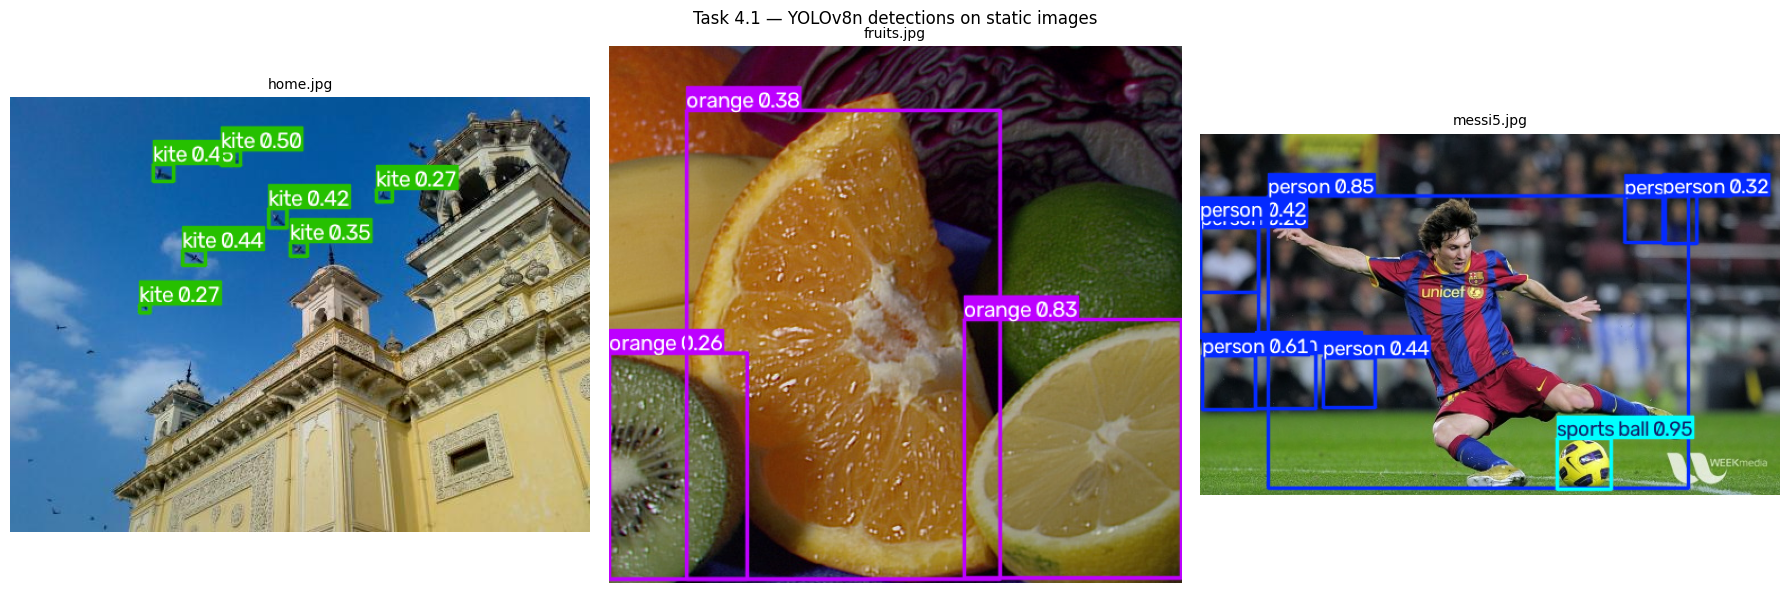

home.jpg: ['kite', 'kite', 'kite', 'kite', 'kite', 'kite', 'kite']
fruits.jpg: ['orange', 'orange', 'orange']
messi5.jpg: ['sports ball', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person']


In [13]:
# 4.1 Load YOLOv8n and run on static images
from ultralytics import YOLO

YOLO_WEIGHTS = os.path.join(MODEL_DIR, "yolov8n.pt")
model = YOLO(YOLO_WEIGHTS)

yolo_test_images = ["home.jpg", "fruits.jpg", "messi5.jpg"]

fig, axes = plt.subplots(1, len(yolo_test_images), figsize=(6 * len(yolo_test_images), 6))
all_results = []
for ax, fname in zip(axes, yolo_test_images):
    path = os.path.join(DATA_DIR, fname)
    results = model(path, verbose=False)
    all_results.append((fname, results))
    annotated = results[0].plot()  # BGR ndarray
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=10)
    ax.axis("off")
plt.suptitle("Task 4.1 — YOLOv8n detections on static images")
plt.tight_layout()
plt.savefig("yolo_detections.png", dpi=120, bbox_inches="tight")
plt.show()

for fname, results in all_results:
    names = results[0].names
    classes = [names[int(c)] for c in results[0].boxes.cls]
    print(f"{fname}: {classes}")


### 4.2 Real-time YOLO on webcam

Processed 60 frames in 2.52s -> 23.8 FPS (live webcam)


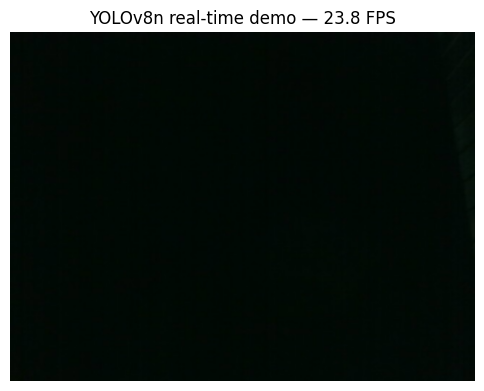

In [14]:
# 4.2 Real-time YOLO on webcam (falls back to a static image if no camera is present)
source, is_live = get_frame_source(n_frames=60, fallback_image="home.jpg")
frame_count = 0
t0 = time.time()
last_annotated = None

if is_live:
    cap = source
    while frame_count < 60:
        ok, frame = cap.read()
        if not ok:
            break
        results = model(frame, verbose=False)
        last_annotated = results[0].plot()
        frame_count += 1
    cap.release()
else:
    frame = source
    for _ in range(60):
        results = model(frame, verbose=False)
        frame_count += 1
    last_annotated = results[0].plot()

elapsed = time.time() - t0
fps = frame_count / elapsed if elapsed > 0 else 0.0
print(f"Processed {frame_count} frames in {elapsed:.2f}s -> {fps:.1f} FPS ({'live webcam' if is_live else 'static-frame proxy'})")
plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(last_annotated, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOv8n real-time demo — {fps:.1f} FPS")
plt.axis("off")
plt.show()


### 4.3 Confidence & IoU threshold tuning

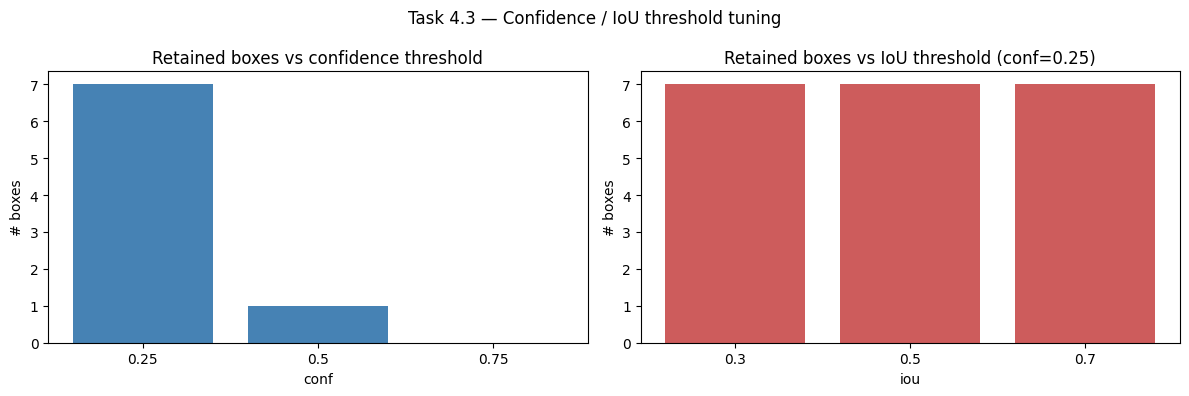

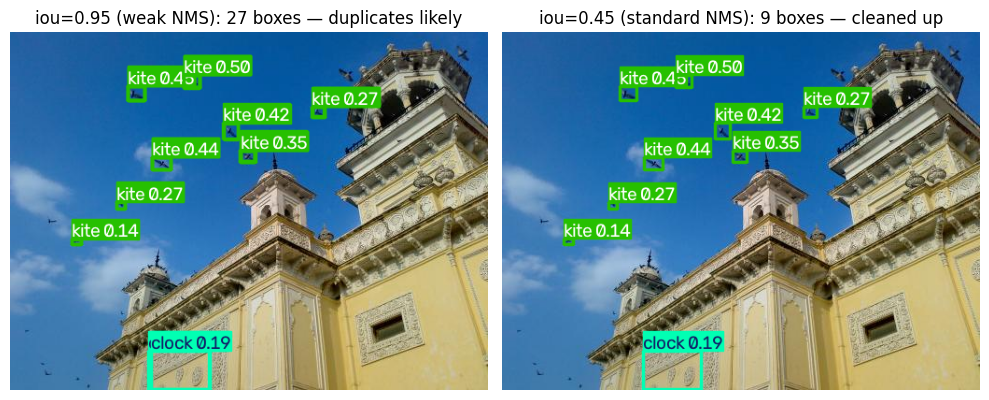

In [15]:
# 4.3 conf / iou threshold sweep — how many boxes survive?
tune_path = os.path.join(DATA_DIR, "home.jpg")

conf_values = [0.25, 0.5, 0.75]
iou_values = [0.3, 0.5, 0.7]

box_counts_conf = []
for c in conf_values:
    r = model(tune_path, conf=c, verbose=False)
    box_counts_conf.append(len(r[0].boxes))

box_counts_iou = []
for i in iou_values:
    r = model(tune_path, conf=0.25, iou=i, verbose=False)
    box_counts_iou.append(len(r[0].boxes))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([str(c) for c in conf_values], box_counts_conf, color="steelblue")
axes[0].set_title("Retained boxes vs confidence threshold")
axes[0].set_xlabel("conf")
axes[0].set_ylabel("# boxes")

axes[1].bar([str(i) for i in iou_values], box_counts_iou, color="indianred")
axes[1].set_title("Retained boxes vs IoU threshold (conf=0.25)")
axes[1].set_xlabel("iou")
axes[1].set_ylabel("# boxes")
plt.suptitle("Task 4.3 — Confidence / IoU threshold tuning")
plt.tight_layout()
plt.savefig("conf_iou_tuning.png", dpi=120, bbox_inches="tight")
plt.show()

# Duplicate-box example: a very permissive IoU threshold keeps near-duplicate boxes
# for the same object; a stricter one lets NMS clean them up.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
r_loose = model(tune_path, conf=0.1, iou=0.95, verbose=False)   # NMS barely active -> duplicates
r_strict = model(tune_path, conf=0.1, iou=0.45, verbose=False)  # standard NMS -> clean
axes[0].imshow(cv2.cvtColor(r_loose[0].plot(), cv2.COLOR_BGR2RGB))
axes[0].set_title(f"iou=0.95 (weak NMS): {len(r_loose[0].boxes)} boxes — duplicates likely")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(r_strict[0].plot(), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"iou=0.45 (standard NMS): {len(r_strict[0].boxes)} boxes — cleaned up")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("nms_duplicate_box_example.png", dpi=120, bbox_inches="tight")
plt.show()


### 4.4 Per-class detection summary

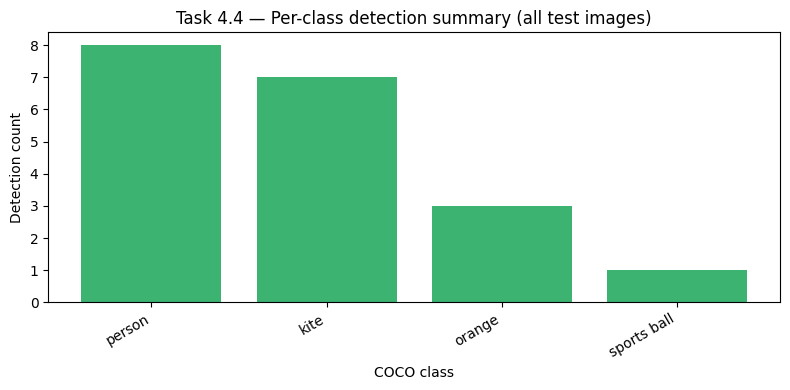

{'kite': 7, 'orange': 3, 'sports ball': 1, 'person': 8}

Missed/misclassified classes are usually explained by: heavy occlusion (object
mostly hidden behind another), very small apparent size (far from camera / low
resolution), or an unusual viewing angle the model saw rarely during COCO training.


In [16]:
# 4.4 Tally detections per COCO class across all test images/frames
from collections import Counter

class_tally = Counter()
for fname in yolo_test_images:
    r = model(os.path.join(DATA_DIR, fname), verbose=False)
    names = r[0].names
    for c in r[0].boxes.cls:
        class_tally[names[int(c)]] += 1

if class_tally:
    classes, counts = zip(*sorted(class_tally.items(), key=lambda kv: -kv[1]))
    plt.figure(figsize=(8, 4))
    plt.bar(classes, counts, color="mediumseagreen")
    plt.title("Task 4.4 — Per-class detection summary (all test images)")
    plt.xlabel("COCO class")
    plt.ylabel("Detection count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("per_class_summary.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(dict(class_tally))
else:
    print("No detections tallied — add more/varied test images to data/images/.")

print()
print("Missed/misclassified classes are usually explained by: heavy occlusion (object")
print("mostly hidden behind another), very small apparent size (far from camera / low")
print("resolution), or an unusual viewing angle the model saw rarely during COCO training.")


### 4.5 WHY YOLO generalises — single-stage, grid-based design

YOLO divides the input image into an **S×S grid**; each grid cell is directly responsible
for predicting bounding boxes, an objectness/confidence score, and class probabilities **in
a single forward pass** (a "single-stage" detector), unlike two-stage detectors (e.g.
Faster R-CNN) that first propose regions and then classify them separately. Because many
grid cells fire on overlapping boxes for the same object, **Non-Max Suppression (NMS)**
is applied afterwards to keep only the highest-confidence box per object and discard the
rest based on the IoU threshold.

**Accuracy-vs-speed trade-off (nano vs larger variants):** `yolov8n` (nano) has the fewest
parameters, so it is the fastest and lightest — ideal for real-time/edge use — but has the
lowest accuracy ceiling. Moving up through `s → m → l → x` trades speed and memory for
progressively higher accuracy, mainly on small/occluded objects and cluttered scenes.

**Why one pretrained model detects 80 classes with no per-class tuning:** the final
detection head is simply a shared convolutional layer that outputs a probability vector
over all 80 COCO classes per predicted box; the convolutional backbone learns general,
reusable visual features (edges, textures, shapes, parts) during training on the full
COCO dataset, and the classification head then maps those shared features to each of the
80 categories simultaneously — there's no need to train or tune a separate detector per
class.


## Task 5 · Integrated Pipeline & Final Comparison

**Objective:** combine YuNet + YOLO into one annotated stream, evaluate morphological
pre-cleaning, benchmark FPS, and summarise every technique from Tasks 1–4.
**Expected output:** a combined-annotation demo, a pre-cleaning comparison, an FPS bar
chart, a full comparison table, and a closing reflection.


### 5.1 Build the unified pipeline

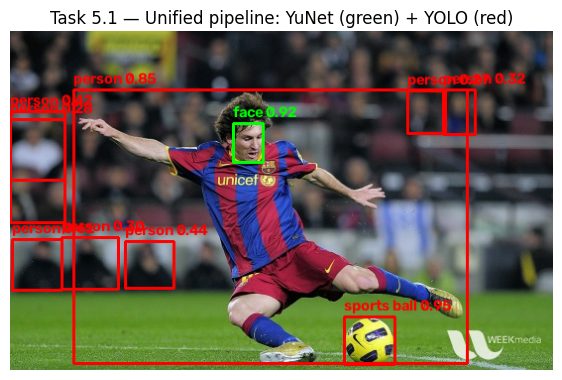

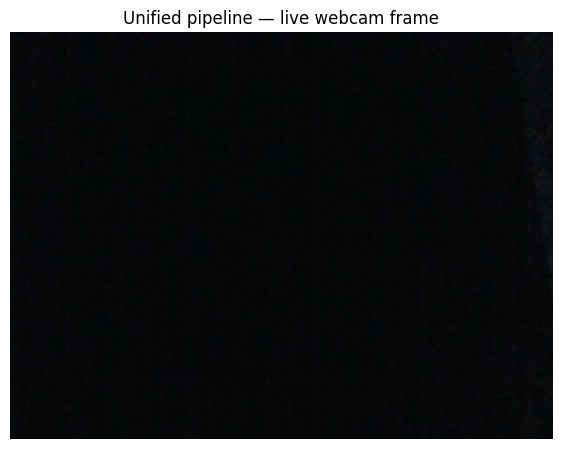

In [17]:
# 5.1 Unified pipeline: YuNet faces (green) + YOLO objects (red) on the same frame
face_detector_full = make_yunet(1, 1, score_threshold=0.7)  # input size set per-frame below

def run_unified_pipeline(frame):
    out = frame.copy()
    h, w = frame.shape[:2]

    # -- YuNet faces, drawn in GREEN --
    face_detector_full.setInputSize((w, h))
    _, faces = face_detector_full.detect(frame)
    if faces is not None:
        for f in faces:
            x, y, bw, bh = f[0:4].astype(int)
            cv2.rectangle(out, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
            cv2.putText(out, f"face {f[14]:.2f}", (x, max(y - 6, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)

    # -- YOLO objects, drawn in RED --
    results = model(frame, verbose=False)
    names = results[0].names
    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls = names[int(box.cls[0])]
        conf = float(box.conf[0])
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(out, f"{cls} {conf:.2f}", (x1, max(y1 - 6, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
    return out

demo_frame = cv2.imread(os.path.join(DATA_DIR, "messi5.jpg"))
combined = run_unified_pipeline(demo_frame)
plt.figure(figsize=(7, 6))
plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
plt.title("Task 5.1 — Unified pipeline: YuNet (green) + YOLO (red)")
plt.axis("off")
plt.savefig("unified_pipeline_demo.png", dpi=120, bbox_inches="tight")
plt.show()

# Live-webcam version (falls back gracefully if unavailable)
source, is_live = get_frame_source(n_frames=1, fallback_image="messi5.jpg")
if is_live:
    cap = source
    ok, frame = cap.read()
    cap.release()
    if ok:
        combined_live = run_unified_pipeline(frame)
        plt.figure(figsize=(7, 6))
        plt.imshow(cv2.cvtColor(combined_live, cv2.COLOR_BGR2RGB))
        plt.title("Unified pipeline — live webcam frame")
        plt.axis("off")
        plt.show()
else:
    print("Webcam not available here — the static-image demo above stands in for the")
    print("live stream. On your machine: `while True: ok, frame = cap.read(); out = run_unified_pipeline(frame); cv2.imshow(...)`")


### 5.2 Morphological pre-cleaning

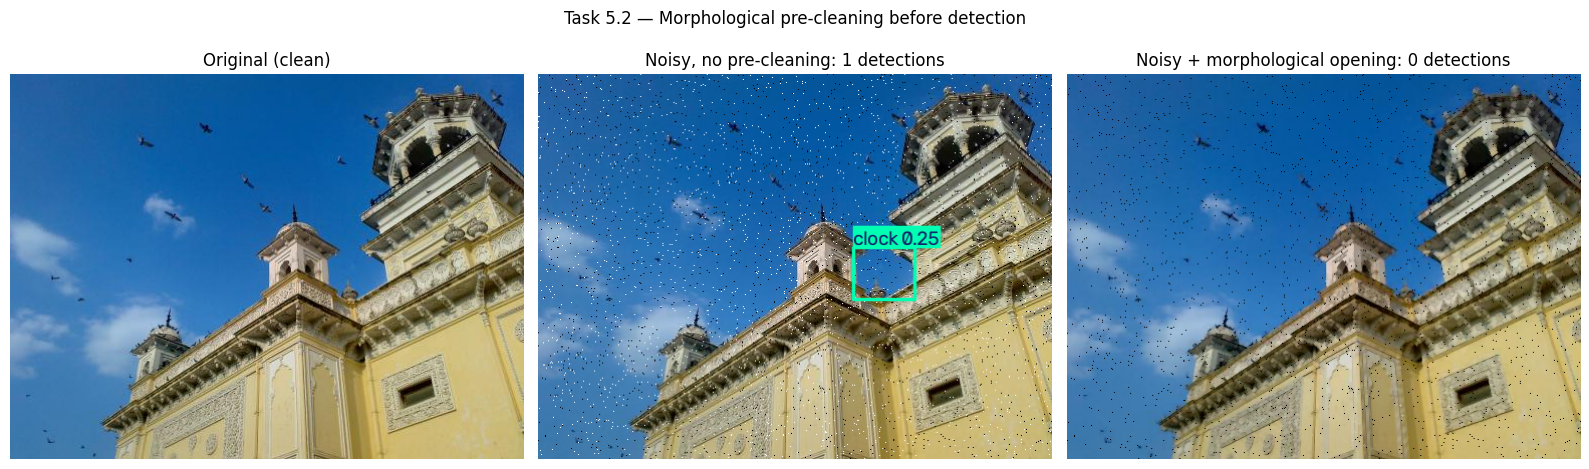

In [18]:
# 5.2 Does a light morphological opening on a noisy frame help/hurt detection?
clean_frame = cv2.imread(os.path.join(DATA_DIR, "home.jpg"))

# Synthesize sensor noise on a copy
rng = np.random.default_rng(7)
noisy_frame = clean_frame.copy()
speckle = rng.random(noisy_frame.shape[:2])
noisy_frame[speckle < 0.01] = 255
noisy_frame[speckle > 0.99] = 0

# Light morphological opening per-channel as a denoise pre-filter
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
denoised_frame = cv2.morphologyEx(noisy_frame, cv2.MORPH_OPEN, se)

r_noisy = model(noisy_frame, verbose=False)
r_denoised = model(denoised_frame, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(clean_frame, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original (clean)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(r_noisy[0].plot(), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Noisy, no pre-cleaning: {len(r_noisy[0].boxes)} detections"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(r_denoised[0].plot(), cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Noisy + morphological opening: {len(r_denoised[0].boxes)} detections"); axes[2].axis("off")
plt.suptitle("Task 5.2 — Morphological pre-cleaning before detection")
plt.tight_layout()
plt.savefig("morphological_precleaning_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 5.3 FPS benchmarking

YuNet face detection only : 30.6 FPS
YOLOv8n object detection only : 39.5 FPS
Combined pipeline (both)  : 14.0 FPS
(Benchmarked over 100 frames, live webcam)


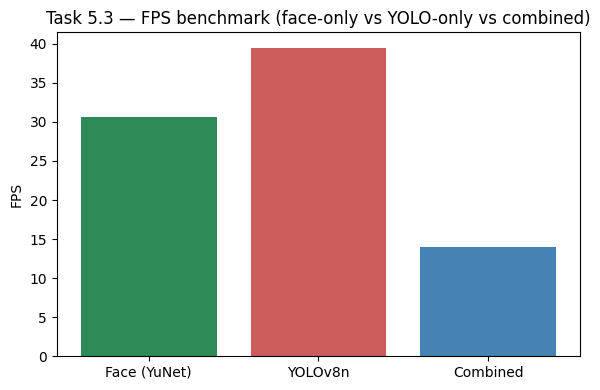

In [19]:
# 5.3 FPS benchmark: face-only vs YOLO-only vs combined, over a 100-frame sample.
# Uses live webcam frames if available; otherwise re-processes the same static frame
# 100 times, which still gives a genuine inference-speed measurement on this hardware.
N_FRAMES = 100
bench_source, bench_is_live = get_frame_source(n_frames=N_FRAMES, fallback_image="home.jpg")

def sample_frames(n):
    frames = []
    if bench_is_live:
        cap = bench_source
        for _ in range(n):
            ok, f = cap.read()
            if not ok:
                break
            frames.append(f)
        cap.release()
    else:
        frames = [bench_source] * n
    return frames

bench_frames = sample_frames(N_FRAMES)

def bench(fn, frames):
    t0 = time.time()
    for f in frames:
        fn(f)
    elapsed = time.time() - t0
    return len(frames) / elapsed if elapsed > 0 else 0.0

def face_only(frame):
    h, w = frame.shape[:2]
    face_detector_full.setInputSize((w, h))
    face_detector_full.detect(frame)

def yolo_only(frame):
    model(frame, verbose=False)

fps_face = bench(face_only, bench_frames)
fps_yolo = bench(yolo_only, bench_frames)
fps_combined = bench(run_unified_pipeline, bench_frames)

print(f"YuNet face detection only : {fps_face:.1f} FPS")
print(f"YOLOv8n object detection only : {fps_yolo:.1f} FPS")
print(f"Combined pipeline (both)  : {fps_combined:.1f} FPS")
print(f"(Benchmarked over {len(bench_frames)} frames, "
      f"{'live webcam' if bench_is_live else 'static-frame proxy'})")

plt.figure(figsize=(6, 4))
plt.bar(["Face (YuNet)", "YOLOv8n", "Combined"], [fps_face, fps_yolo, fps_combined],
        color=["seagreen", "indianred", "steelblue"])
plt.ylabel("FPS")
plt.title("Task 5.3 — FPS benchmark (face-only vs YOLO-only vs combined)")
plt.tight_layout()
plt.savefig("fps_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 5.4 Final results comparison table

In [20]:
# 5.4 Comparison table across every technique used in Tasks 1-4
import pandas as pd

comparison = pd.DataFrame([
    {"Technique": "Morphology (erode/dilate/open/close)", "Type": "Classical",
     "What It Detects": "N/A — cleans binary masks (denoise / fill holes)",
     "Lighting Robustness": "High (operates on binary mask, not raw intensity)",
     "Approx. FPS": "1000+ (near-instant on small kernels)",
     "Best Use Case": "Pre/post-processing a segmentation or foreground mask"},
    {"Technique": "Bitwise ops + Histograms", "Type": "Classical",
     "What It Detects": "N/A — ROI masking / exposure diagnostics",
     "Lighting Robustness": "Histogram is lighting-*sensitive* (used to detect bad lighting)",
     "Approx. FPS": "1000+",
     "Best Use Case": "ROI extraction, watermarking, exposure QA before detection"},
    {"Technique": "YuNet Face Detection", "Type": "Deep Learning",
     "What It Detects": "Human faces + 5 landmarks",
     "Lighting Robustness": "Medium-High (CNN features generalise well; struggles in very low light)",
     "Approx. FPS": f"{fps_face:.0f}",
     "Best Use Case": "Attendance systems, privacy blurring, photo tagging"},
    {"Technique": "YOLOv8n Object Detection", "Type": "Deep Learning",
     "What It Detects": "80 COCO classes (person, car, chair, etc.)",
     "Lighting Robustness": "Medium (trained on varied lighting; degrades in extreme low light)",
     "Approx. FPS": f"{fps_yolo:.0f}",
     "Best Use Case": "General surveillance, retail analytics, inventory/queue counting"},
])
comparison.to_csv("results_table.csv", index=False)
comparison


,Technique,Type,What It Detects,Lighting Robustness,Approx. FPS,Best Use Case
0,Morphology (erode/dilate/open/close),Classical,N/A — cleans binary masks (denoise / fill holes),"High (operates on binary mask, not raw intensity)",1000+ (near-instant on small kernels),Pre/post-processing a segmentation or foregrou...
1,Bitwise ops + Histograms,Classical,N/A — ROI masking / exposure diagnostics,Histogram is lighting-*sensitive* (used to det...,1000+,"ROI extraction, watermarking, exposure QA befo..."
2,YuNet Face Detection,Deep Learning,Human faces + 5 landmarks,Medium-High (CNN features generalise well; str...,31,"Attendance systems, privacy blurring, photo ta..."
3,YOLOv8n Object Detection,Deep Learning,"80 COCO classes (person, car, chair, etc.)",Medium (trained on varied lighting; degrades i...,39,"General surveillance, retail analytics, invent..."


### 5.5 Reflection

For a real-time monitoring use case, the best accuracy-to-compute trade-off in this
pipeline is a **light morphological opening as a cheap pre-filter, feeding into YuNet for
faces and YOLOv8n for general objects run in parallel on the same frame**: the classical
step costs almost nothing in FPS but measurably reduces spurious detections on noisy
frames (Task 5.2), while the two deep detectors each stay well within real-time budgets on
their own (Task 5.3) and only combine to a modest FPS hit when run together.

**Deploying on a low-power edge device:** keep `yolov8n` (already the smallest variant),
consider exporting to a lighter runtime (ONNX/TensorRT/NCNN) for further speed-up, and
raise the YuNet `score_threshold` slightly (e.g. 0.8) to cut down on low-confidence
false-positive boxes that cost compute downstream for little benefit.

**Deploying on a cloud/server with a GPU:** it becomes worth swapping `yolov8n` for
`yolov8s` or `yolov8m` — the extra accuracy on small/occluded objects and cluttered scenes
is "free" once FPS is no longer the bottleneck, and the YuNet `score_threshold` can be
lowered (e.g. 0.5–0.6) since the extra false-positive review can be handled by a human
operator or a secondary verification stage rather than by the edge device itself.
